# Logistic Regression — Telco Customer Churn Prediction

**Dataset:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Algorithm:** Logistic Regression (Supervised Learning)  
**Goal:** Predict whether a customer will churn (Yes/No) based on service usage and account details.

## 1. Import Libraries

In [24]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import subprocess
from imblearn.over_sampling import SMOTE

print("Libraries loaded")

Libraries loaded


## 2. Run Preprocessing

The shared `preprocess.py` script handles:
- Dropping `customerID`
- Fixing `TotalCharges` data type
- Handling missing values
- Label encoding categorical columns
- Standard scaling all features

In [25]:
subprocess.run(["python", "preprocess.py"])
print("Preprocessing completed")

Preprocessing completed


## 3. Load Processed Data

In [26]:
df = pd.read_csv("../../../data/processed/churn_processed.csv")

print("Shape:", df.shape)
df.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,-1.009430,-0.440327,1.035617,-0.652305,-1.280248,-3.056334,0.062666,-1.183614,-0.917837,1.242875,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,0.399805,-1.161694,-0.994194,0
1,0.990658,-0.440327,-0.965608,-0.652305,0.064303,0.327189,-0.991564,-1.183614,1.408012,-1.028998,1.245441,-0.924267,-1.112632,-1.121501,0.373926,-1.206361,1.336636,-0.260878,-0.173740,0
2,0.990658,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.991564,-1.183614,1.408012,1.242875,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,1.336636,-0.363923,-0.959649,1
3,0.990658,-0.440327,-0.965608,-0.652305,0.512486,-3.056334,0.062666,-1.183614,1.408012,-1.028998,1.245441,1.396963,-1.112632,-1.121501,0.373926,-1.206361,-1.473857,-0.747850,-0.195248,0
4,-1.009430,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.991564,0.172835,-0.917837,-1.028998,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,0.399805,0.196178,-0.940457,1


## 4. Separate Features & Target

In [27]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature columns:", list(X.columns))
print("\nTarget distribution:")
print(y.value_counts())

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 5. Train / Test Split

> `stratify=y` ensures both train and test sets maintain the same churn ratio.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (5625, 19)
Test size : (1407, 19)


## 6. Handle Class Imbalance with SMOTE

The Telco dataset is imbalanced — churned customers are a minority class.  
**SMOTE** (Synthetic Minority Oversampling Technique) generates synthetic samples for the minority class to balance the training set.

In [29]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64


## 7. Baseline Logistic Regression Model

**Logistic Regression** is a linear classification algorithm that models the probability of a binary outcome.  
It uses the sigmoid function to output values between 0 and 1, making it well-suited for binary classification tasks like churn prediction.

In [30]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_sm, y_train_sm)
print("Baseline model training complete!")

Baseline model training complete!


## 8. Baseline Model Predictions & Evaluation

In [31]:
y_pred = lr_model.predict(X_test)

print("Baseline Logistic Regression Results:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")

Baseline Logistic Regression Results:
  Accuracy  : 0.7356
  Precision : 0.5017
  Recall    : 0.7914
  F1 Score  : 0.6141


## 9. Classification Report

In [32]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



## 10. Confusion Matrix — Baseline

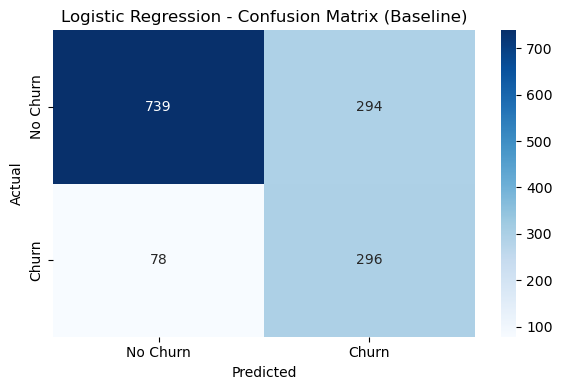

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Logistic Regression - Confusion Matrix (Baseline)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 11. Cross Validation

5-fold cross validation is used to verify the model does not overfit on the training set.

In [34]:
cv_scores = cross_val_score(lr_model, X_train_sm, y_train_sm, cv=5, scoring='accuracy')

print(f"Cross Validation Scores : {cv_scores}")
print(f"Mean CV Accuracy        : {cv_scores.mean():.4f}")
print(f"Standard Deviation      : {cv_scores.std():.4f}")

Cross Validation Scores : [0.76150121 0.77663438 0.80024213 0.78874092 0.79176755]
Mean CV Accuracy        : 0.7838
Standard Deviation      : 0.0135


## 12. Hyperparameter Tuning with GridSearchCV

Key hyperparameters tuned:
- **C** — Regularization strength (smaller = stronger regularization)
- **solver** — Optimization algorithm used to fit the model

In [35]:
param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_sm, y_train_sm)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score  :", round(grid_search.best_score_, 4))

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score  : 0.7841


## 13. Tuned Model Predictions & Evaluation

In [36]:
best_model = grid_search.best_estimator_
y_pred2 = best_model.predict(X_test)

print("Tuned Logistic Regression Results:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred2):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred2):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred2):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred2):.4f}")

Tuned Logistic Regression Results:
  Accuracy  : 0.7363
  Precision : 0.5025
  Recall    : 0.7914
  F1 Score  : 0.6147


## 14. Confusion Matrix — Tuned Model

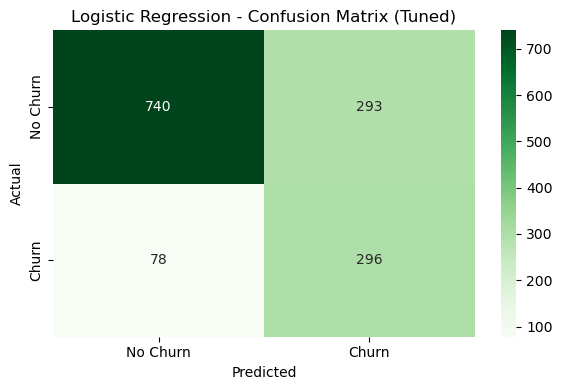

In [38]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.title("Logistic Regression - Confusion Matrix (Tuned)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 15. Feature Importance (Coefficients)

In Logistic Regression, the magnitude of each coefficient indicates how strongly that feature influences the prediction.  
Positive coefficients increase churn probability; negative coefficients decrease it.

C:\Users\User\AppData\Local\Temp\ipykernel_30204\1989309720.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')


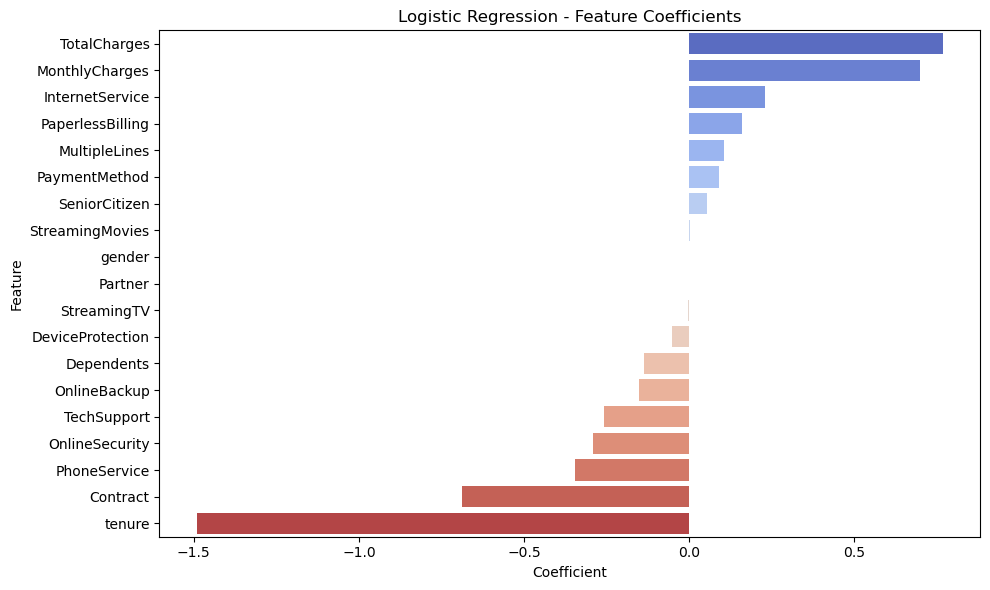

In [40]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Logistic Regression - Feature Coefficients")
plt.tight_layout()
plt.show()

## 16. ROC Curve

The ROC curve shows the trade-off between **True Positive Rate** and **False Positive Rate** at different classification thresholds.  
**AUC (Area Under Curve)** closer to 1.0 means better model performance.

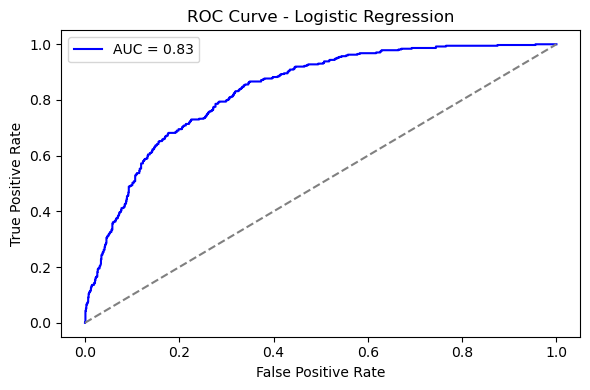

In [42]:
from sklearn.metrics import roc_curve, auc

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='blue')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Model Comparison

Comparing Baseline vs Tuned Logistic Regression performance.

In [43]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred2)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred2)
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.735608,0.614108
1,Tuned Logistic Regression,0.736318,0.614746


## 18. Save Model

In [44]:
joblib.dump(best_model, "lr_churn_model.pkl")
joblib.dump(X.columns, "lr_feature_columns.pkl")

print("Model saved successfully")

Model saved successfully


## 19. Final Summary

In [45]:
print("Logistic Regression Model Completed Successfully")

Logistic Regression Model Completed Successfully
